In [ ]:
# ==========================================================
# RadioML Pickle - Modulation Classification with PyTorch
# Model: CNN + BiLSTM + separate SNR branch
# Target: ONE-HOT ENCODING
# Dataset: RadioML2016.10b (10 modulations, 100k samples)
# ==========================================================

import os
import random
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ===================
# 1. Reproducibility
# ===================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ================================
# 2. Load RadioML2016.10b dataset
# ================================
PKL_PATH = # Use your our path to find "RML2016-10b.dat"

def load_radioml_pickle(pkl_path):
    with open(pkl_path, "rb") as f:
        try:
            data = pickle.load(f, encoding="latin1")
        except TypeError:
            data = pickle.load(f)

    X_list, y_list, snr_list = [], [], []

    mods = sorted(list(set(k[0] for k in data.keys())))
    snrs = sorted(list(set(k[1] for k in data.keys())))

    print("Detected modulations:", mods)
    print("Detected SNRs:", snrs)

    for (mod, snr), arr in data.items():
        arr = np.array(arr, dtype=np.float32)

        if arr.shape[1] == 2:
            arr = np.transpose(arr, (0, 2, 1)) 

        n = arr.shape[0]
        X_list.append(arr)
        y_list.extend([mod] * n)
        snr_list.extend([snr] * n)

    X = np.concatenate(X_list, axis=0)
    labels = np.array(y_list)
    snr = np.array(snr_list, dtype=np.float32).reshape(-1, 1)

    return X, labels, snr, mods, snrs

X_signal, labels, snr, mods, snrs = load_radioml_pickle(PKL_PATH)

print("X_signal:", X_signal.shape)  
print("labels:", labels.shape)
print("snr:", snr.shape)

# ============================
# 3. Label Encoding + ONE-HOT
# ============================
label_encoder = LabelEncoder()
y_int = label_encoder.fit_transform(labels)

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

# One-hot encoding
y = np.eye(num_classes)[y_int].astype(np.float32)

print("Classes:", class_names)  
print("One-hot labels:", y.shape)

# ============================
# 4. Train / Val / Test split
# ============================
indices = np.arange(len(X_signal))

idx_train, idx_temp = train_test_split(
    indices, test_size=0.30, stratify=y_int, random_state=42
)

idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, stratify=y_int[idx_temp], random_state=42
)

Xsig_train = X_signal[idx_train]
Xsig_val   = X_signal[idx_val]
Xsig_test  = X_signal[idx_test]

y_train = y[idx_train]
y_val   = y[idx_val]
y_test  = y[idx_test]

snr_train_raw = snr[idx_train]
snr_val_raw   = snr[idx_val]
snr_test_raw  = snr[idx_test]

print(f"Train size: {len(Xsig_train)}, Val size: {len(Xsig_val)}, Test size: {len(Xsig_test)}")

# ========================
# 5. Standardize SNR only
# ========================
snr_scaler = StandardScaler()
snr_train = snr_scaler.fit_transform(snr_train_raw)
snr_val   = snr_scaler.transform(snr_val_raw)
snr_test  = snr_scaler.transform(snr_test_raw)

# ===================
# 6. PyTorch Dataset
# ===================
class RadioMLDataset(Dataset):
    def __init__(self, X_signal, X_snr, y):
        self.X_signal = torch.tensor(X_signal, dtype=torch.float32)
        self.X_snr = torch.tensor(X_snr, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_signal[idx], self.X_snr[idx], self.y[idx]

BATCH_SIZE = 256

train_loader = DataLoader(RadioMLDataset(Xsig_train, snr_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(RadioMLDataset(Xsig_val, snr_val, y_val),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(RadioMLDataset(Xsig_test, snr_test, y_test),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ====================================
# 7. Model: CNN + BiLSTM + SNR branch
# ====================================
class CNNBiLSTMWithSNR(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.conv_block = nn.Sequential(
            nn.Conv1d(2, 64, 5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, 5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 128, 3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.signal_fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.snr_fc = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(144, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x_signal, x_snr):
        x = x_signal.permute(0, 2, 1)  
        x = self.conv_block(x)          
        x = x.permute(0, 2, 1)          
        x, _ = self.lstm(x)             
        x = self.signal_fc(x[:, -1, :]) 

        s = self.snr_fc(x_snr)          
        fused = torch.cat([x, s], dim=1) 
        return self.classifier(fused)

model = CNNBiLSTMWithSNR(num_classes).to(device)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# ==================
# 8. Training setup
# ==================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3, verbose=True
)

EPOCHS = 50
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

# =============================
# 9. Train / Evaluate function
# =============================
def run_epoch(model, loader, criterion, optimizer=None):
    model.train() if optimizer else model.eval()

    running_loss = 0.0
    preds_all, targets_all = [], []

    with torch.set_grad_enabled(optimizer is not None):
        for x_signal, x_snr, y_batch in loader:
            x_signal = x_signal.to(device)
            x_snr = x_snr.to(device)
            y_batch = y_batch.to(device)

            outputs = model(x_signal, x_snr)
            loss = criterion(outputs, y_batch)

            if optimizer:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * y_batch.size(0)

            preds = torch.argmax(outputs, dim=1)
            targets = torch.argmax(y_batch, dim=1)

            preds_all.extend(preds.cpu().numpy())
            targets_all.extend(targets.cpu().numpy())

    return (running_loss / len(loader.dataset),
            accuracy_score(targets_all, preds_all),
            np.array(preds_all),
            np.array(targets_all))

# ==================
# 10. Training loop
# ==================
best_val_acc = 0.0
best_epoch = 0

for epoch in range(EPOCHS):
    tr_loss, tr_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_acc, _, _ = run_epoch(model, val_loader, criterion)

    scheduler.step(va_acc)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_model_rml2016.10b.pth")

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss={tr_loss:.4f} Acc={tr_acc:.4f} | "
          f"Val Loss={va_loss:.4f} Acc={va_acc:.4f}")

print(f"\nBest validation accuracy: {best_val_acc:.4f} at epoch {best_epoch}")

# ====================
# 11. Test evaluation
# ====================
model.load_state_dict(torch.load("best_model_rml2016.10b.pth"))
model.eval()

test_loss, test_acc, y_pred, y_true = run_epoch(model, test_loader, criterion)

print("\n" + "="*50)
print(f"Test Accuracy: {test_acc:.4f}")
print("="*50)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))



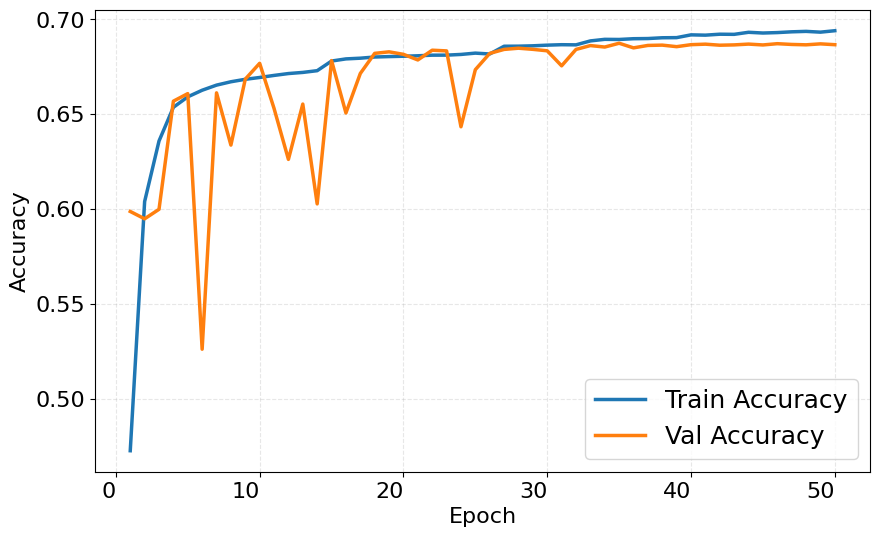

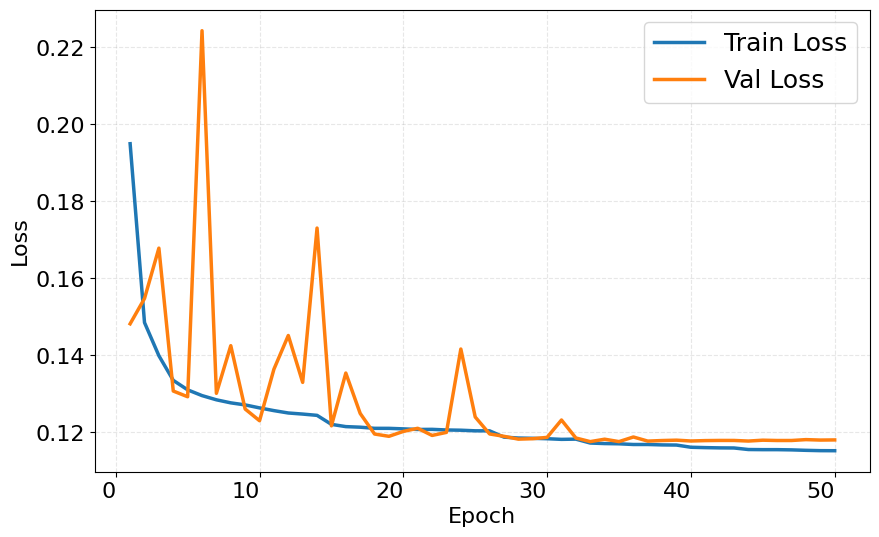

In [ ]:
# ===========================
# 12. Accuracy / Loss curves
# ===========================
epochs_range = range(1, EPOCHS + 1)

# Figure 8 : Accuracy Curves
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy", linewidth=2.5)
plt.plot(epochs_range, history["val_acc"], label="Val Accuracy", linewidth=2.5)
plt.xlabel("Epoch", fontsize=16)
plt.ylabel("Accuracy", fontsize=16)
plt.xticks(fontsize=16, rotation=0, ha='right')
plt.yticks(fontsize=16, rotation=0)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=18)
plt.grid(True, alpha=0.3)
plt.savefig("Figure_8.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Figure 9 : Loss Curves
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, history["train_loss"], label="Train Loss", linewidth=2.5)
plt.plot(epochs_range, history["val_loss"], label="Val Loss", linewidth=2.5)
plt.xlabel("Epoch", fontsize=16)
plt.ylabel("Loss", fontsize=16)
plt.xticks(fontsize=16, rotation=0, ha='right')
plt.yticks(fontsize=16, rotation=0)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=18)
plt.grid(True, alpha=0.3)
plt.savefig("Figure_9.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()  



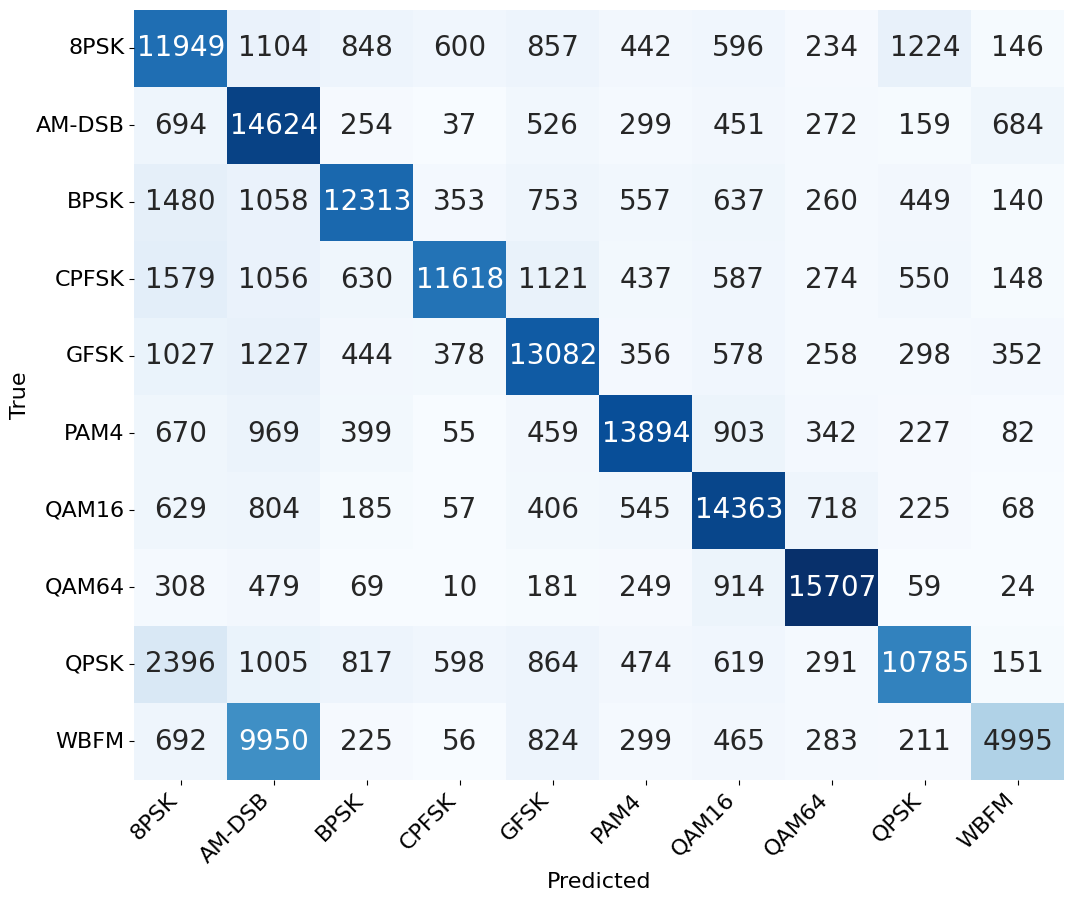

In [ ]:
# =====================
# 13. Confusion Matrix
# =====================

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names, cbar=False, annot_kws={"size": 20},
            cmap="Blues")
plt.xlabel("Predicted", fontsize=16)
plt.ylabel("True", fontsize=16)
plt.xticks(fontsize=16, rotation=45, ha='right')
plt.yticks(fontsize=16, rotation=0)

# Save figure
plt.savefig('Figure_10.png', dpi=300, bbox_inches='tight')

plt.show()

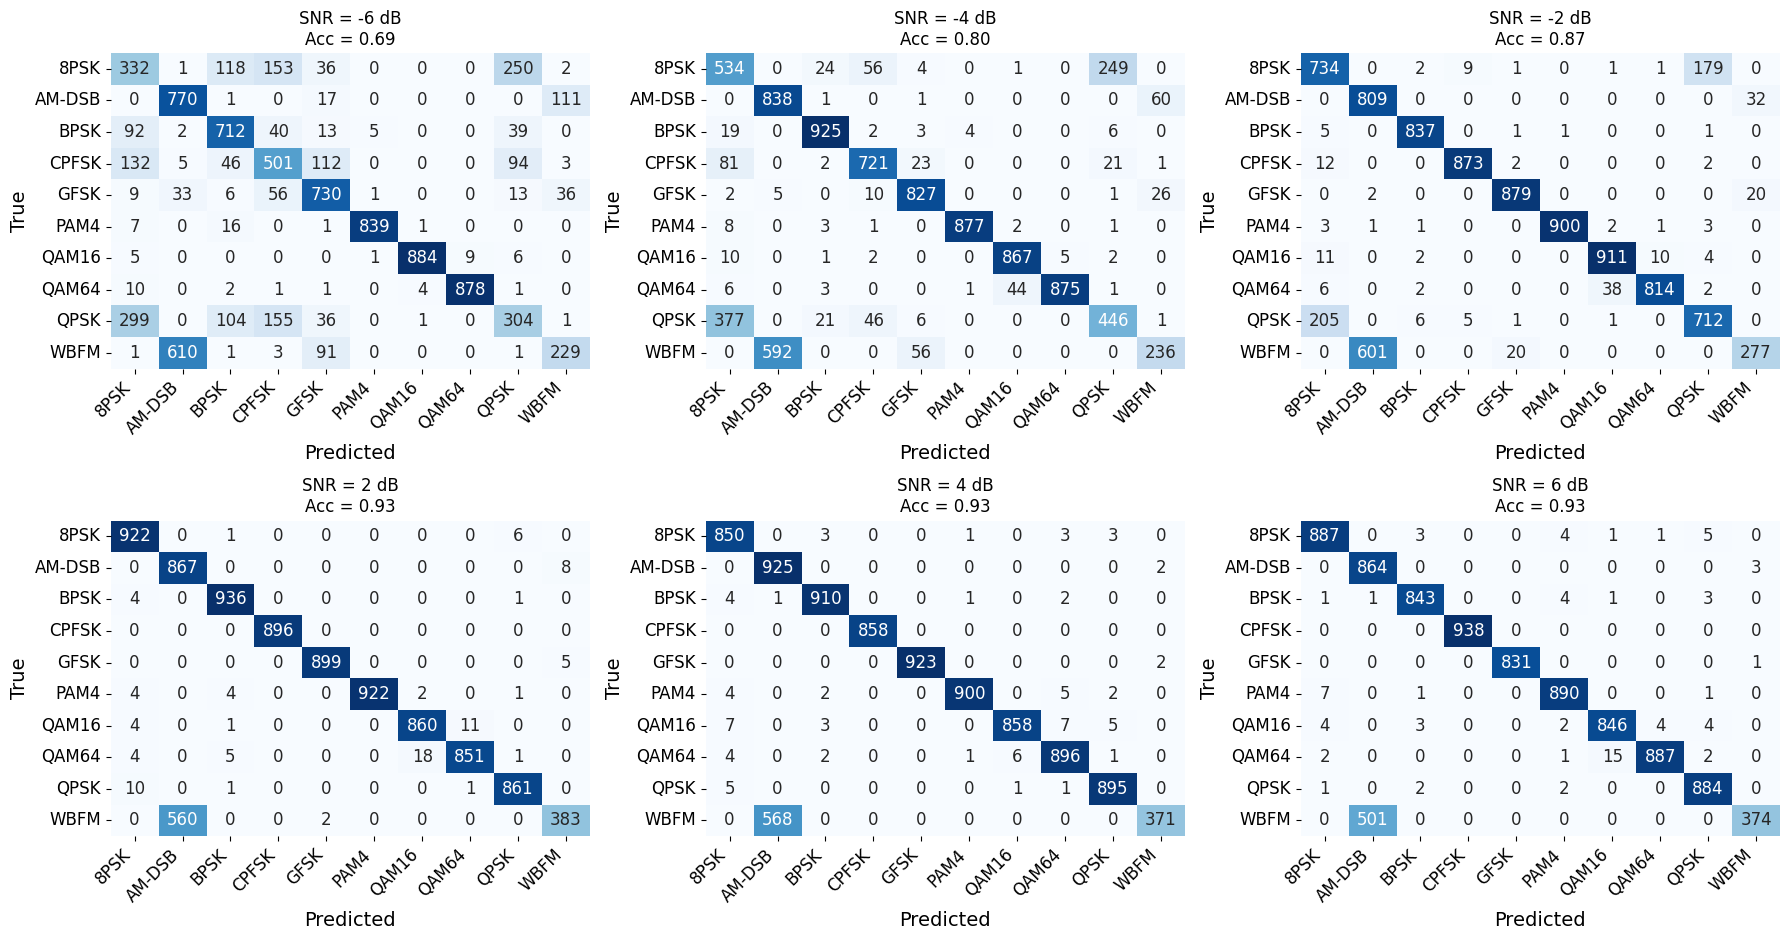

In [ ]:
# ===================================================
# 14. Confusion Matrices at Selected SNRs (Subplots)
# ===================================================
snr_values_to_plot = [-6, -4, -2, 2, 4, 6]
snr_test_flat = snr_test_raw.flatten()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, snr_val in enumerate(snr_values_to_plot):
    ax = axes[i]
    mask = (snr_test_flat == snr_val)

    if np.sum(mask) == 0:
        ax.set_title(f"SNR = {snr_val} dB\n(No samples)")
        ax.axis("off")
        continue

    y_true_snr = y_true[mask]
    y_pred_snr = y_pred[mask]

    cm = confusion_matrix(y_true_snr, y_pred_snr)
    acc = accuracy_score(y_true_snr, y_pred_snr)


    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,annot_kws={"size": 12})
                
    ax.set_title(f"SNR = {snr_val} dB\nAcc = {acc:.2f}", fontsize=12)
    ax.set_xlabel("Predicted", fontsize=14)
    ax.set_ylabel("True", fontsize=14)

    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=12)
    ax.set_yticklabels(class_names, rotation=0, fontsize=12)
    
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save figure
plt.savefig("Figure_11.png", dpi=300, bbox_inches="tight")
plt.show()

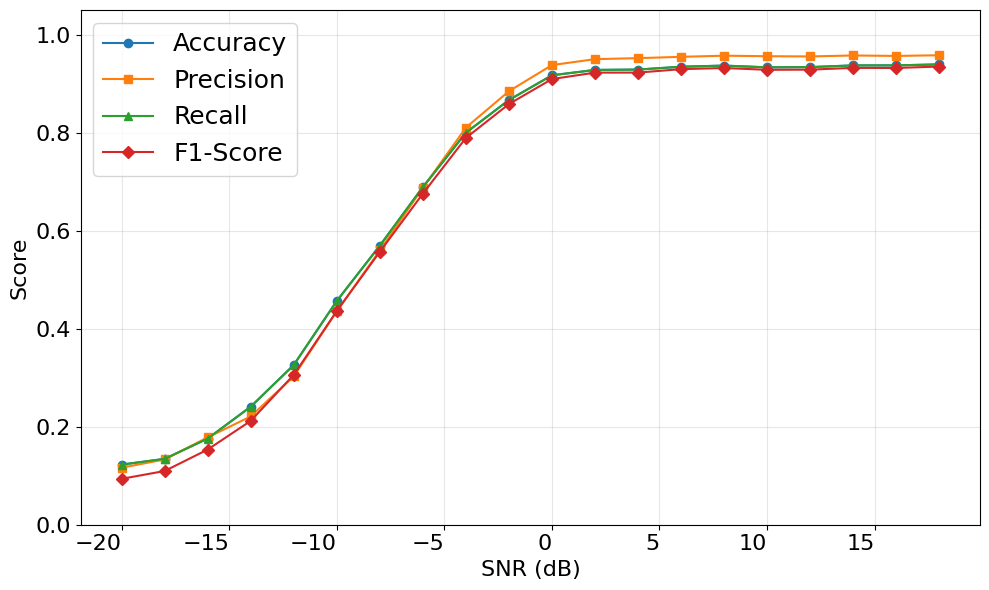


SUMMARY TABLE - METRICS BY SNR
SNR (dB)   Accuracy     Precision    Recall       F1-Score     Samples   
----------------------------------------------------------------------
-20        0.1226       0.1163       0.1226       0.0936       9075      
-18        0.1343       0.1331       0.1343       0.1096       8858      
-16        0.1758       0.1782       0.1758       0.1533       9103      
-14        0.2408       0.2209       0.2408       0.2119       8991      
-12        0.3259       0.3027       0.3259       0.3057       8985      
-10        0.4565       0.4354       0.4565       0.4359       9028      
-8         0.5692       0.5595       0.5692       0.5567       8986      
-6         0.6886       0.6871       0.6886       0.6753       8973      
-4         0.7996       0.8099       0.7996       0.7890       8937      
-2         0.8662       0.8843       0.8662       0.8581       8942      
0          0.9168       0.9376       0.9168       0.9091       8930      
2        

In [ ]:
# ==========================================================================
# 15. Evaluation by SNR with full metrics (Accuracy, Precision, Recall, F1)
# ==========================================================================

from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Flatten SNR array for test set
snr_test_flat = snr_test_raw.flatten()
unique_snrs = sorted(np.unique(snr_test_flat))

snr_metrics = {}  # store metrics per SNR

for snr_value in unique_snrs:
    mask = (snr_test_flat == snr_value)
    if np.sum(mask) == 0:
        continue
    
    y_true_snr = y_true[mask]
    y_pred_snr = y_pred[mask]
    
    acc = accuracy_score(y_true_snr, y_pred_snr)
    report = classification_report(y_true_snr, y_pred_snr, output_dict=True, zero_division=0)
    
    weighted_avg = report.get('weighted avg', {})
    macro_avg = report.get('macro avg', {})
    
    snr_metrics[snr_value] = {
        'accuracy': acc,
        'precision_weighted': weighted_avg.get('precision', 0),
        'recall_weighted': weighted_avg.get('recall', 0),
        'f1_weighted': weighted_avg.get('f1-score', 0),
        'precision_macro': macro_avg.get('precision', 0),
        'recall_macro': macro_avg.get('recall', 0),
        'f1_macro': macro_avg.get('f1-score', 0),
        'num_samples': np.sum(mask)
    }
    
    
# ========================
# 16. Plot metrics by SNR
# ========================

# Extract data for plotting
snr_values_list = list(snr_metrics.keys())
accuracy_list = [snr_metrics[s]['accuracy'] for s in snr_values_list]
precision_list = [snr_metrics[s]['precision_weighted'] for s in snr_values_list]
recall_list = [snr_metrics[s]['recall_weighted'] for s in snr_values_list]
f1_list = [snr_metrics[s]['f1_weighted'] for s in snr_values_list]

# ==========================
# 17. Combined metrics plot
# ==========================
plt.figure(figsize=(10,6))
plt.plot(snr_values_list, accuracy_list, marker='o', label='Accuracy', color='#1f77b4')
plt.plot(snr_values_list, precision_list, marker='s', label='Precision', color='#ff7f0e')
plt.plot(snr_values_list, recall_list, marker='^', label='Recall', color='#2ca02c')
plt.plot(snr_values_list, f1_list, marker='D', label='F1-Score', color='#d62728')
plt.xlabel('SNR (dB)', fontsize=16)
plt.ylabel('Score', fontsize=16)
plt.legend(loc='best', fontsize=18)
plt.xticks(fontsize=16, rotation=0, ha='right')
plt.yticks(fontsize=16, rotation=0)
plt.grid(True, alpha=0.3)
plt.ylim(0,1.05)
plt.tight_layout()
plt.savefig("Figure_12.png", dpi=300, bbox_inches="tight")
plt.show()

# ==================
# 18. Summary table
# ==================
print("\n" + "="*80)
print("SUMMARY TABLE - METRICS BY SNR")
print("="*80)
print(f"{'SNR (dB)':<10} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Samples':<10}")
print("-"*70)
for snr_val in snr_values_list:
    m = snr_metrics[snr_val]
    print(f"{int(snr_val):<10} {m['accuracy']:<12.4f} {m['precision_weighted']:<12.4f} {m['recall_weighted']:<12.4f} {m['f1_weighted']:<12.4f} {m['num_samples']:<10}")

# Average metrics across all SNRs
avg_accuracy = np.mean(accuracy_list)
avg_precision = np.mean(precision_list)
avg_recall = np.mean(recall_list)
avg_f1 = np.mean(f1_list)
print(f"\nAverage metrics across all SNR levels:")
print(f"  Accuracy:  {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall:    {avg_recall:.4f}")
print(f"  F1-Score:  {avg_f1:.4f}")
print("="*80)